# Gaussian Process Regression (GPR) Foreground Removal
## Senior Honours Project — Grace Tait

This notebook implements GPR foreground removal for HI intensity mapping data simulated with the `meer21cm` package.

### Structure
1. [Imports & Setup](#1-imports--setup)
2. [Simulation Setup](#2-simulation-setup)
3. [Covariance Analysis](#3-covariance-analysis)
4. [Kernel Exploration](#4-kernel-exploration)
5. [PCA Foreground Removal (Benchmark)](#5-pca-foreground-removal-benchmark)
6. [GPR Functions](#6-gpr-functions)
7. [Kernel Parameter Optimisation](#7-kernel-parameter-optimisation)
8. [MCMC — Model 1: RBF without Spectral Index](#8-mcmc--model-1-rbf-without-spectral-index)
9. [MCMC — Model 2: RBF with Spectral Index](#9-mcmc--model-2-rbf-with-spectral-index)
10. [Matérn Kernel Comparison](#10-matern-kernel-comparison)
11. [Model Comparison (Log Marginal Likelihood)](#11-model-comparison-log-marginal-likelihood)
12. [GPR Power Spectrum with MCMC Uncertainty](#12-gpr-power-spectrum-with-mcmc-uncertainty)


## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import glob

# meer21cm simulation tools
from meer21cm import MockSimulation
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
from meer21cm.util import pca_clean

# GPR kernel functions (defined in gpr.py)
from gpr import *

# Optimisation
from scipy import optimize
from scipy.special import gamma, kv

# MCMC
import emcee
import corner

# Parallel processing
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
# ── Global plot settings ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

# ── Helper: save plots to project output folder ───────────────────────────
def save_project_plot(fig, week_number, filename):
    """Save a matplotlib figure to outputs/weekN/filename."""
    base_path = "/Users/gracetait/shproject/senior_honours_project/outputs"
    target_dir = os.path.join(base_path, f"week{week_number}")
    os.makedirs(target_dir, exist_ok=True)
    filepath = os.path.join(target_dir, filename)
    fig.savefig(filepath, bbox_inches='tight')
    print(f"Successfully saved: {filepath}")

# ── Number of CPU cores for parallelisation ───────────────────────────────
num_processes = os.cpu_count()
print(f"Available CPU cores: {num_processes}")

Available CPU cores: 8


## 2. Simulation Setup

Generate the mock HI signal, foreground, and thermal noise maps using `meer21cm`.

- **HI signal**: mock 21cm intensity map with seed=42 for reproducibility
- **Foreground**: Haslam-based synchrotron foreground with spectral index γ = -2.7 (injected truth)
- **Noise**: Gaussian white noise with σ = 1.21 × 10⁻³ K (from MeerKLASS 2024)

In [3]:
# ── Generate HI mock simulation ───────────────────────────────────────────
mock = MockSimulation(
    survey='meerklass_2021',
    band='L',
    flat_sky=True,
    seed=42,
    omega_hi=5e-4,
    mean_amp_1='average_hi_temp',
    tracer_bias_1=1.0,
)

# ── Generate foreground simulation ────────────────────────────────────────
# Injected spectral index: sp_indx_for_haslam_backend = -2.7 (this is the truth we try to recover)
fgsim = ForegroundSimulation(
    hp_nside=128,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend='haslam',
    sp_indx_for_haslam_backend=-2.7,
)

# ── Extract maps ──────────────────────────────────────────────────────────
hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
fg_map = fgsim.fg_wcs_cube(mock.nu)

# ── Generate thermal noise ────────────────────────────────────────────────
# Gaussian white noise scaled by survey weights — purely diagonal covariance
sigma_noise = 1.21e-3  # K (from MeerKLASS 2024, Table 1)
noise_map = np.random.default_rng(mock.seed).normal(0, sigma_noise, hi_map.shape) * mock.w_HI

# ── Total observed map ────────────────────────────────────────────────────
tot_map = hi_map + fg_map + noise_map

print(f"Frequency range: {mock.nu[0]/1e6:.1f} – {mock.nu[-1]/1e6:.1f} MHz")
print(f"Number of frequency channels: {len(mock.nu)}")
print(f"Map shape (ra, dec, freq): {hi_map.shape}")
print(f"HI amplitude (rms):        {hi_map.std():.2e} K")
print(f"Foreground amplitude (rms): {fg_map.std():.2e} K")
print(f"Noise amplitude (rms):      {noise_map.std():.2e} K")
print(f"Foreground/HI ratio:        {fg_map.std()/hi_map.std():.0f}x")

Frequency range: 971.2 – 1023.6 MHz
Number of frequency channels: 252
Map shape (ra, dec, freq): (133, 73, 252)
HI amplitude (rms):        1.90e-04 K
Foreground amplitude (rms): 1.86e-01 K
Noise amplitude (rms):      1.18e-03 K
Foreground/HI ratio:        980x


## 3. Covariance Analysis

Extract frequency-frequency covariance matrices for each component. The covariance structure motivates our choice of GPR kernels:
- **Foreground**: smooth, slowly varying → RBF (squared exponential) kernel
- **HI signal**: rapidly varying, short correlation length → exponential kernel  
- **Noise**: purely diagonal (white noise) → diagonal kernel

In [4]:
# ── Extract covariance matrices from each component ──────────────────────
# pca_clean with return_analysis=True returns (covariance, eigenvalues, eigenvectors, ...)
# N_fg=0 means no modes are removed — we just want the covariance
cov_hi,    _, _, _ = pca_clean(hi_map,    0, weights=mock.w_HI, return_analysis=True, mean_center=True)
cov_fg,    _, _, _ = pca_clean(fg_map,    0, weights=mock.w_HI, return_analysis=True, mean_center=True)
cov_noise, _, _, _ = pca_clean(noise_map, 0, weights=mock.w_HI, return_analysis=True, mean_center=True)
cov_tot,   _, _, _ = pca_clean(tot_map,   0, weights=mock.w_HI, return_analysis=True, mean_center=True)

print(f"cov_tot shape:              {cov_tot.shape}")
print(f"cov_tot diagonal mean:      {np.diag(cov_tot).mean():.4f}")
print(f"cov_tot off-diagonal mean:  {cov_tot[0,1]:.4f}")
print(f"cov_fg diagonal mean:       {np.diag(cov_fg).mean():.4f}")
print(f"cov_hi diagonal mean:       {np.diag(cov_hi).mean():.6f}")
print(f"cov_noise diagonal mean:    {np.diag(cov_noise).mean():.6f}")

cov_tot shape:              (252, 252)
cov_tot diagonal mean:      0.0280
cov_tot off-diagonal mean:  0.0322
cov_fg diagonal mean:       0.0280
cov_hi diagonal mean:       0.000000
cov_noise diagonal mean:    0.000001


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/covariance_matrices_all.pdf


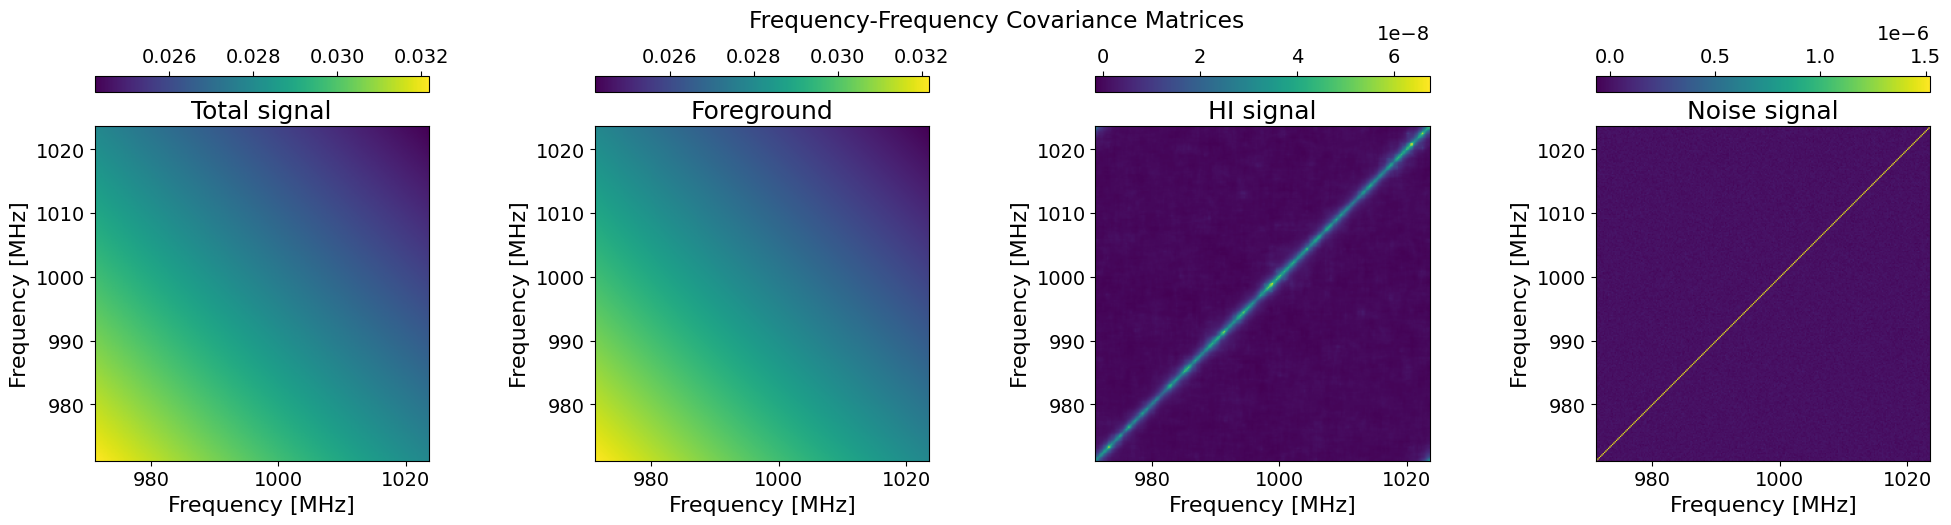

In [5]:
# ── Plot all four covariance matrices ─────────────────────────────────────
extent = [mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6]
titles = ['Total signal', 'Foreground', 'HI signal', 'Noise signal']
covs   = [cov_tot, cov_fg, cov_hi, cov_noise]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), layout='constrained')
for ax, cov, title in zip(axes, covs, titles):
    im = ax.imshow(cov, origin='lower', extent=extent)
    fig.colorbar(im, ax=ax, location='top', fraction=0.05, pad=0.02)
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Frequency [MHz]')
    ax.set_title(title)
plt.suptitle('Frequency-Frequency Covariance Matrices', y=1.02)
save_project_plot(fig, week_number=3, filename='covariance_matrices_all.pdf')
plt.show()

True sigma_fg (from fg_map): 0.1699 K
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/foreground_coherence.pdf


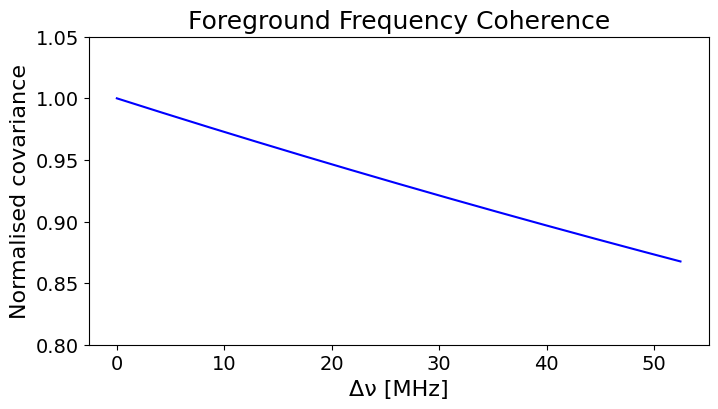

Estimated l_fg (from coherence): 369.3 MHz
Note: l_fg >> bandwidth confirms it cannot be constrained from this data alone


In [6]:
# ── Foreground frequency coherence ────────────────────────────────────────
# Shows how correlated the foreground is as a function of frequency separation
# A slowly decaying curve confirms the foreground is spectrally smooth (large l_fg)
fg_flat  = fg_map.reshape(-1, len(mock.nu)).T   # (n_freq, n_pixels)
cov_fg_direct = np.cov(fg_flat)
nu_MHz   = mock.nu / 1e6
delta_nu = nu_MHz - nu_MHz[0]
cov_row  = cov_fg_direct[0] / cov_fg_direct[0, 0]  # normalised

sigma_fg_true = np.sqrt(np.mean(np.diag(cov_fg_direct)))
print(f"True sigma_fg (from fg_map): {sigma_fg_true:.4f} K")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(delta_nu, cov_row, color='blue')
ax.set_xlabel('Δν [MHz]')
ax.set_ylabel('Normalised covariance')
ax.set_title('Foreground Frequency Coherence')
ax.set_ylim(0.8, 1.05)
save_project_plot(fig, week_number=3, filename='foreground_coherence.pdf')
plt.show()

# Direct estimate of foreground length scale
l_estimate = -delta_nu[-1] / np.log(cov_row[-1])
print(f"Estimated l_fg (from coherence): {l_estimate:.1f} MHz")
print("Note: l_fg >> bandwidth confirms it cannot be constrained from this data alone")

## 4. Kernel Exploration

Explore how the exponential and RBF kernels behave for different parameter values.
This motivates the choice of kernel for each component.

In [7]:
# ── Initial parameter estimates from covariance matrices ──────────────────
sigma_hi_kern = np.sqrt(np.diagonal(cov_hi).mean())
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())
l_hi          = 1.0    # MHz — short correlation length for HI
l_fg          = 400.0  # MHz — long correlation length for foreground
sp_indx_fg    = -2.7   # spectral index starting guess (= injected truth)

print("Initial kernel parameter estimates:")
print(f"  sigma_hi_kern: {sigma_hi_kern:.6f}")
print(f"  sigma_fg_kern: {sigma_fg_kern:.6f}")
print(f"  l_hi:          {l_hi} MHz")
print(f"  l_fg:          {l_fg} MHz")
print(f"  sp_indx_fg:    {sp_indx_fg}")

Initial kernel parameter estimates:
  sigma_hi_kern: 0.000190
  sigma_fg_kern: 0.167264
  l_hi:          1.0 MHz
  l_fg:          400.0 MHz
  sp_indx_fg:    -2.7


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/exp_kernel_hi_comparison.pdf


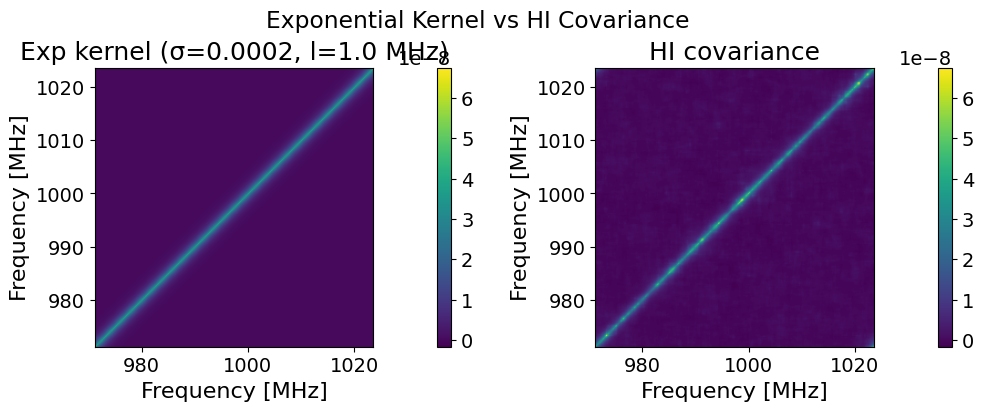

In [8]:
# ── Exponential kernel: HI signal model ───────────────────────────────────
# The exponential kernel (Matérn η=1/2) is ideal for the spectrally varying HI signal
# l controls the width of the diagonal stripe — small l = narrow = rapidly varying
exp_kern_hi = exponential_kernel(mock.nu/1e6, mock.nu/1e6, sigma_hi_kern, l_hi)

extent = [mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6]
vmin = min(exp_kern_hi.min(), cov_hi.min())
vmax = max(exp_kern_hi.max(), cov_hi.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
im = axes[0].imshow(exp_kern_hi, origin='lower', extent=extent, vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0])
axes[0].set_title(f'Exp kernel (σ={sigma_hi_kern:.4f}, l={l_hi} MHz)')
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')

im = axes[1].imshow(cov_hi, origin='lower', extent=extent, vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1])
axes[1].set_title('HI covariance')
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')

plt.suptitle('Exponential Kernel vs HI Covariance')
save_project_plot(fig, week_number=3, filename='exp_kernel_hi_comparison.pdf')
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/rbf_kernel_fg_comparison.pdf


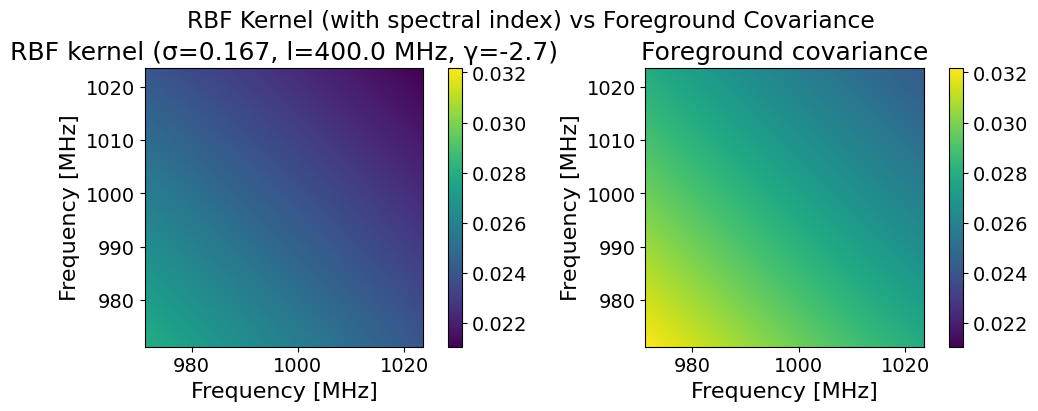

In [9]:
# ── RBF kernel with spectral index: foreground model ──────────────────────
# The RBF kernel (Matérn η→∞) is ideal for the smooth foreground signal
# The spectral index rescaling (novel addition) allows amplitude to scale with frequency
# This physically models the power-law spectrum of synchrotron emission: T(ν) ∝ ν^γ
rbf_kern_fg = rbf_kernel(mock.nu/1e6, mock.nu/1e6, sigma_fg_kern, l_fg, sp_indx_fg)

vmin = min(rbf_kern_fg.min(), cov_fg.min())
vmax = max(rbf_kern_fg.max(), cov_fg.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
im = axes[0].imshow(rbf_kern_fg, origin='lower', extent=extent, vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0])
axes[0].set_title(f'RBF kernel (σ={sigma_fg_kern:.3f}, l={l_fg} MHz, γ={sp_indx_fg})')
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')

im = axes[1].imshow(cov_fg, origin='lower', extent=extent, vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[1])
axes[1].set_title('Foreground covariance')
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')

plt.suptitle('RBF Kernel (with spectral index) vs Foreground Covariance')
save_project_plot(fig, week_number=3, filename='rbf_kernel_fg_comparison.pdf')
plt.show()

## 5. PCA Foreground Removal (Benchmark)

PCA removes the N largest variance modes from the data. Since the foreground dominates
the first few eigenmodes, removing 3 modes effectively cleans the foreground.

This serves as the **benchmark** to compare GPR performance against.

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/pca_1d_power_spectrum_benchmark.pdf


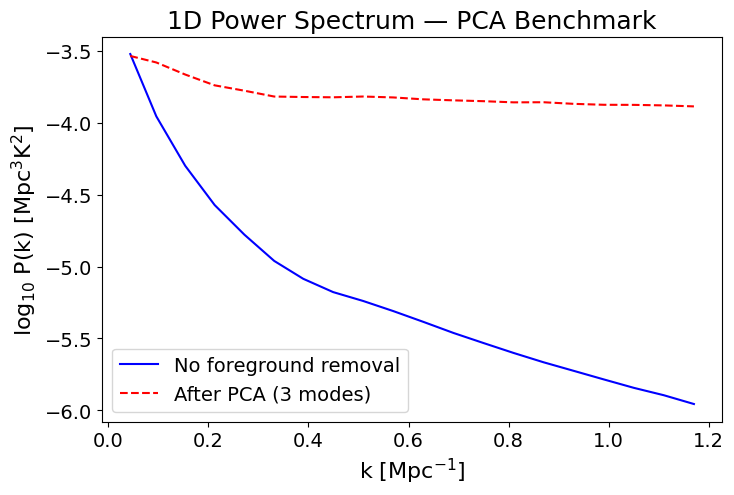

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/pca_cylindrical_power_spectrum_benchmark.pdf


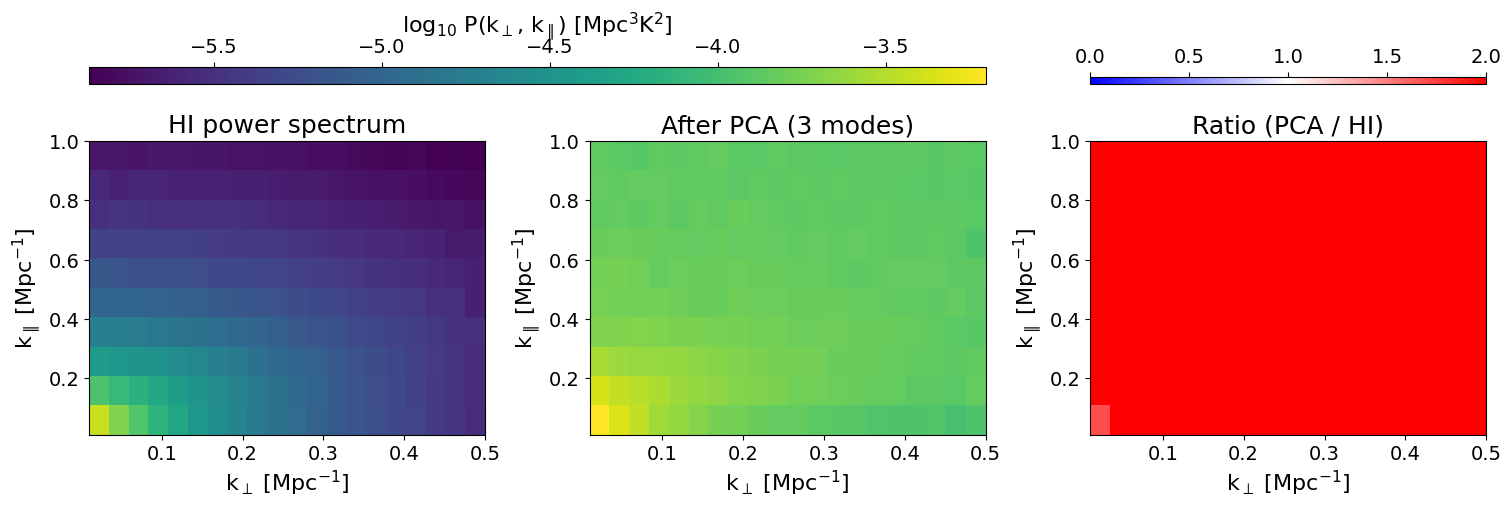

In [10]:
# ── PCA foreground removal ────────────────────────────────────────────────
# Remove 3 dominant foreground modes from the total map
res_map_pca = pca_clean(tot_map, 3, weights=mock.w_HI, return_analysis=False, mean_center=True)

# ── Compute power spectra ─────────────────────────────────────────────────
mock.kparabins = np.linspace(0.01, 1, 11)
mock.kperpbins = np.linspace(0.01, 0.5, 21)
mock.k1dbins   = np.linspace(0, 1.2, 21)

mock.data = hi_map
mock.grid_data_to_field()
power_cy_hi, _ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_hi, k_1d, _ = mock.get_1d_power(mock.auto_power_3d_1)

mock.data = res_map_pca
mock.grid_data_to_field()
power_cy_pca, _ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_pca, _, _ = mock.get_1d_power(mock.auto_power_3d_1)

# ── 1D power spectrum plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_1d, np.log10(power_1d_hi),  label='No foreground removal', color='blue', linewidth=1.5)
ax.plot(k_1d, np.log10(power_1d_pca), label='After PCA (3 modes)',   color='red',  linewidth=1.5, ls='--')
ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel(r'log$_{10}$ P(k) [Mpc$^{3}$K$^2$]')
ax.set_title('1D Power Spectrum — PCA Benchmark')
ax.legend()
save_project_plot(fig, week_number=5, filename='pca_1d_power_spectrum_benchmark.pdf')
plt.show()

# ── Cylindrical power spectrum ────────────────────────────────────────────
vmin = np.log10([power_cy_hi.min(), power_cy_pca.min()]).min()
vmax = np.log10([power_cy_hi.max(), power_cy_pca.max()]).max()
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),  vmin=vmin, vmax=vmax)
axes[0].set_title('HI power spectrum')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_pca.T), vmin=vmin, vmax=vmax)
axes[1].set_title('After PCA (3 modes)')
cbar = plt.colorbar(im, ax=axes[:2], location='top', aspect=50, pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [Mpc$^3$K$^2$]')
im2 = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, power_cy_pca.T/power_cy_hi.T, cmap='bwr', vmin=0, vmax=2)
axes[2].set_title('Ratio (PCA / HI)')
plt.colorbar(im2, ax=axes[2], location='top', aspect=50, pad=0.1)
for ax in axes:
    ax.set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
    ax.set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
save_project_plot(fig, week_number=5, filename='pca_cylindrical_power_spectrum_benchmark.pdf')
plt.show()

## 6. GPR Functions

Define all kernel functions and the log marginal likelihood used for optimisation.

The **log marginal likelihood (LML)** is the objective function:
$$\log p(\mathbf{d} | \boldsymbol{\theta}) = -\frac{1}{2} \text{tr}(C_{\text{data}} K^{-1}) - \frac{1}{2} \log |K|$$

where $C_{\text{data}}$ is the observed covariance and $K = K_{\text{HI}} + K_{\text{fg}}$ is the model kernel.

In [11]:
# ── Kernel functions ──────────────────────────────────────────────────────

def matern_kernel(x, y, sigma, l, eta):
    """
    Matérn kernel with smoothness parameter eta.
    - eta = 1/2: exponential kernel (HI signal)
    - eta = 3/2: medium smoothness
    - eta = 5/2: smooth foreground
    - eta → inf: RBF (smoothest foreground)
    """
    x = np.atleast_1d(x).ravel()[:, None]
    y = np.atleast_1d(y).ravel()[None, :]
    kernel = (
        sigma**2
        * 2**(1 - eta) / gamma(eta)
        * (np.sqrt(2*eta) * np.abs(x - y) / l)**eta
        * kv(eta, np.sqrt(2*eta) * np.abs(x - y) / l)
    )
    kernel[x - y == 0] = sigma**2
    return kernel


def rbf_kernel(x, y, sigma, l, sp_indx=0.0):
    """
    RBF (squared exponential) kernel with optional spectral index rescaling.
    Novel extension: sp_indx allows the amplitude to scale as a power law with frequency,
    physically motivated by synchrotron emission: T(nu) proportional to nu^sp_indx.
    sp_indx = 0 recovers the standard RBF kernel.
    """
    rescale = (x / x.ravel()[0])**sp_indx
    rescale = rescale.ravel()
    rescale = rescale[None, :] * rescale[:, None]
    x = np.atleast_1d(x).ravel()[:, None]
    y = np.atleast_1d(y).ravel()[None, :]
    return np.nan_to_num(sigma**2 * np.exp(-(x - y)**2 / (2*l**2)) * rescale)


def rbf_kernel_no_sp_indx(x, y, sigma, l):
    """Standard RBF kernel without spectral index (sp_indx = 0)."""
    x = np.atleast_1d(x).ravel()[:, None]
    y = np.atleast_1d(y).ravel()[None, :]
    return np.nan_to_num(sigma**2 * np.exp(-(x - y)**2 / (2*l**2)))


def exponential_kernel(x, y, sigma, l):
    """
    Exponential kernel (Matérn eta=1/2).
    Used to model the HI signal + thermal noise (short correlation length).
    """
    x = np.atleast_1d(x).ravel()[:, None]
    y = np.atleast_1d(y).ravel()[None, :]
    return np.nan_to_num(sigma**2 * np.exp(-np.abs(x - y) / l))


# ── Log marginal likelihood ────────────────────────────────────────────────
def log_marginal_likelihood(cov_data, kernel):
    """
    Log marginal likelihood: measures how well the kernel model explains the data covariance.
    LML = -0.5 * tr(C_data @ K^-1) - 0.5 * log|K|
    Higher LML = better fit.
    """
    chi2 = -0.5 * np.trace(cov_data @ np.linalg.inv(kernel))
    sign, log_det = np.linalg.slogdet(kernel)
    if sign <= 0:
        log_det = np.inf
    return chi2 - 0.5 * log_det


# ── Objective functions for optimisation ──────────────────────────────────

def function_to_optimise(params, xarr=None, cov_tot=None, minimise=True):
    """
    Model 1: HI (exponential) + Foreground (RBF with spectral index).
    Parameters: [sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg]
    """
    sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg = params
    k_hi  = exponential_kernel(xarr, xarr, sigma_hi, l_hi)
    k_fg  = rbf_kernel(xarr, xarr, sigma_fg, l_fg, sp_indx_fg)
    k_tot = k_hi + k_fg
    lml   = log_marginal_likelihood(cov_tot, k_tot)
    return -lml if minimise else lml


def function_to_optimise_no_sp_indx(params, xarr=None, cov_tot=None, minimise=True):
    """
    Model 2: HI (exponential) + Foreground (standard RBF, no spectral index).
    Parameters: [sigma_hi, sigma_fg, l_hi, l_fg]
    """
    sigma_hi, sigma_fg, l_hi, l_fg = params
    k_hi  = exponential_kernel(xarr, xarr, sigma_hi, l_hi)
    k_fg  = rbf_kernel_no_sp_indx(xarr, xarr, sigma_fg, l_fg)
    k_tot = k_hi + k_fg
    lml   = log_marginal_likelihood(cov_tot, k_tot)
    return -lml if minimise else lml


def function_to_optimise_matern(params, xarr=None, cov_tot=None, minimise=True):
    """
    Model 3: HI (exponential) + Foreground (Matérn with free eta).
    Parameters: [sigma_hi, sigma_fg, l_hi, l_fg, eta_fg]
    """
    sigma_hi, sigma_fg, l_hi, l_fg, eta_fg = params
    k_hi  = exponential_kernel(xarr, xarr, sigma_hi, l_hi)
    k_fg  = matern_kernel(xarr, xarr, sigma_fg, l_fg, eta_fg)
    k_tot = k_hi + k_fg
    lml   = log_marginal_likelihood(cov_tot, k_tot)
    return -lml if minimise else lml

In [12]:
# ── Foreground removal and power spectrum utility ─────────────────────────

def gpr_foreground_removal(fitted_pars, sp_indx_fg=True):
    """
    Apply GPR Wiener filter to remove foreground from tot_map.
    
    The GP conditional mean gives the best estimate of the HI signal:
        res_map = [I - K_fg @ (K_fg + K_hi)^{-1}] @ tot_map
                = K_hi @ (K_fg + K_hi)^{-1} @ tot_map
    
    Parameters
    ----------
    fitted_pars : array
        [sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg] or [sigma_hi, sigma_fg, l_hi, l_fg]
    sp_indx_fg : bool
        Whether to use the spectral index RBF model (True) or standard RBF (False)
    
    Returns
    -------
    res_map : array — cleaned map
    noise_residual : array — noise contribution to cleaned map (for noise subtraction)
    """
    k_hi = exponential_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[0], fitted_pars[2])
    
    if sp_indx_fg:
        k_fg = rbf_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3], fitted_pars[4])
    else:
        k_fg = rbf_kernel_no_sp_indx(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3])
    
    k_tot_fitted = k_fg + k_hi
    wiener       = k_fg @ np.linalg.inv(k_tot_fitted)
    
    # Cleaned map: subtract GP estimate of foreground
    fg_remov  = np.einsum('ij, abj->abi', wiener, tot_map)
    res_map   = tot_map - fg_remov
    
    # Noise residual: used to subtract noise power from power spectrum
    noise_residual = np.einsum(
        'ij, abj->abi',
        np.eye(mock.nu.size) - wiener,
        noise_map
    )
    return res_map, noise_residual


def compute_power_spectra(res_map, noise_residual):
    """
    Compute 1D and cylindrical power spectra from cleaned map,
    with noise power subtracted.
    
    Returns power_1d_hi, power_1d_res, power_cy_hi, power_cy_res, k_1d
    """
    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)
    mock.k1dbins   = np.linspace(0, 1.2, 21)

    mock.data = hi_map
    mock.grid_data_to_field()
    power_cy_hi, _ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_hi, k_1d, _ = mock.get_1d_power(mock.auto_power_3d_1)

    mock.data = res_map
    mock.grid_data_to_field()
    power_cy_res, _ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_res, _, _ = mock.get_1d_power(mock.auto_power_3d_1)

    mock.data = noise_residual
    mock.grid_data_to_field()
    power_cy_noise, _ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_noise, _, _ = mock.get_1d_power(mock.auto_power_3d_1)

    power_cy_res -= power_cy_noise
    power_1d_res -= power_1d_noise

    return power_1d_hi, power_1d_res, power_cy_hi, power_cy_res, k_1d


def plot_gpr_power_spectra(fitted_pars, sp_indx_fg=True, method='gpr', save_plot=False, week_number=None):
    """Run GPR removal and plot 1D and cylindrical power spectra."""
    res_map, noise_residual = gpr_foreground_removal(fitted_pars, sp_indx_fg)
    power_1d_hi, power_1d_res, power_cy_hi, power_cy_res, k_1d = compute_power_spectra(res_map, noise_residual)

    # 1D log power spectrum
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(k_1d, np.log10(power_1d_hi),  label='No foreground removal', color='blue', linewidth=1.5)
    ax.plot(k_1d, np.log10(power_1d_res), label='After GPR removal',     color='red',  linewidth=1.5, ls='--')
    ax.set_xlabel('k [Mpc$^{-1}$]')
    ax.set_ylabel(r'log$_{10}$ P(k) [Mpc$^3$K$^2$]')
    ax.set_title(f'1D Power Spectrum — GPR ({method})')
    ax.legend()
    if save_plot:
        save_project_plot(fig, week_number=week_number, filename=f'gpr_1d_power_{method}.pdf')
    plt.show()

    # Cylindrical power spectrum
    vmin = np.log10([power_cy_hi.min(), power_cy_res.min()]).min()
    vmax = np.log10([power_cy_hi.max(), power_cy_res.max()]).max()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
    axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),  vmin=vmin, vmax=vmax)
    axes[0].set_title('HI power spectrum')
    im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T), vmin=vmin, vmax=vmax)
    axes[1].set_title('After GPR removal')
    cbar = plt.colorbar(im, ax=axes[:2], location='top', aspect=50, pad=0.1)
    cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [Mpc$^3$K$^2$]')
    im2 = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, power_cy_res.T/power_cy_hi.T, cmap='bwr')
    axes[2].set_title('Ratio')
    plt.colorbar(im2, ax=axes[2], location='top', aspect=50, pad=0.1)
    for ax in axes:
        ax.set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
        ax.set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
    if save_plot:
        save_project_plot(fig, week_number=week_number, filename=f'gpr_cylindrical_{method}.pdf')
    plt.show()

In [13]:
# ── Kernel comparison plots ───────────────────────────────────────────────

def plot_kernel_comparison(fitted_pars, sp_indx_fg=True, method='gpr',
                            save_plot=False, week_number=None):
    """
    Compare fitted HI kernel vs noise covariance,
    and fitted foreground kernel vs foreground covariance.
    Useful for diagnosing how well the optimisation has converged.
    """
    extent = [mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6]

    k_hi = exponential_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[0], fitted_pars[2])
    if sp_indx_fg:
        k_fg = rbf_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3], fitted_pars[4])
    else:
        k_fg = rbf_kernel_no_sp_indx(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3])

    fig, axes = plt.subplots(1, 4, figsize=(20, 5), layout='constrained')
    
    # HI kernel vs noise covariance
    vmin = min(k_hi.min(), cov_noise.min())
    vmax = max(k_hi.max(), cov_noise.max())
    im = axes[0].imshow(k_hi,      origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[0], location='top')
    axes[0].set_title('Fitted HI + noise kernel')
    axes[0].set_xlabel('Frequency [MHz]')
    axes[0].set_ylabel('Frequency [MHz]')

    im = axes[1].imshow(cov_noise, origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[1], location='top')
    axes[1].set_title('Noise covariance')
    axes[1].set_xlabel('Frequency [MHz]')

    # Foreground kernel vs foreground covariance
    vmin = min(k_fg.min(), cov_fg.min())
    vmax = max(k_fg.max(), cov_fg.max())
    im = axes[2].imshow(k_fg,    origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[2], location='top')
    axes[2].set_title('Best fit foreground kernel')
    axes[2].set_xlabel('Frequency [MHz]')

    im = axes[3].imshow(cov_fg,  origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[3], location='top')
    axes[3].set_title('Foreground covariance')
    axes[3].set_xlabel('Frequency [MHz]')

    if save_plot:
        save_project_plot(fig, week_number=week_number,
                          filename=f'kernel_comparison_{method}.pdf')
    plt.show()

## 7. Kernel Parameter Optimisation

Use a **two-stage differential evolution** approach to find the best-fit kernel parameters:

**Stage 1**: Fit the foreground kernel parameters to the off-diagonal structure of `cov_tot`.
The diagonal is dominated by HI + noise, so zeroing it gives an approximation of the foreground covariance.

**Stage 2**: Use stage 1 results as starting point for full joint optimisation of all parameters
against `cov_tot` using the log marginal likelihood.

> **Note**: `workers=1` is required in Jupyter notebooks — multiprocessing causes pickle errors
> when functions are defined interactively.

In [14]:
# ── Stage 1: Fit foreground kernel to off-diagonal covariance ─────────────
# Rationale: the off-diagonal elements of cov_tot are dominated by the smooth foreground,
# so we can get a good initial estimate of sigma_fg, l_fg, sp_indx_fg without HI interference

def fit_fg_only(params, xarr=None, cov_fg_approx=None):
    """Fit foreground kernel to approximate foreground covariance (squared residuals)."""
    sigma_fg, l_fg, sp_indx_fg = params
    k_fg     = rbf_kernel(xarr, xarr, sigma_fg, l_fg, sp_indx_fg)
    residual = np.sum((cov_fg_approx - k_fg)**2)
    return residual

# Approximate foreground covariance: zero the diagonal (HI + noise dominated)
cov_fg_approx = cov_tot.copy()
np.fill_diagonal(cov_fg_approx, 0)

# Subsample for speed: every 4th channel gives 63x63 matrix (~16x faster)
n               = 4
xarr_sub        = (mock.nu / 1e6)[::n]
cov_fg_approx_sub = cov_fg_approx[::n, ::n]
cov_tot_sub     = cov_tot[::n, ::n]

x0_fg    = np.array([0.17, 500.0, -2.7])
bounds_fg = [(1e-6, 0.5), (100.0, 5000.0), (-5.0, -0.1)]

print("Running Stage 1: foreground-only fit...")
result_stage1 = optimize.differential_evolution(
    func=fit_fg_only,
    args=(xarr_sub, cov_fg_approx_sub),
    bounds=bounds_fg,
    x0=x0_fg,
    seed=42,
    maxiter=2000,
    popsize=15,
    polish=True,
    workers=1,  # workers=1 required in Jupyter
    disp=True
)
sigma_fg_init, l_fg_init, sp_indx_fg_init = result_stage1.x
print(f"\nStage 1 results:")
print(f"  sigma_fg:   {sigma_fg_init:.4f}")
print(f"  l_fg:       {l_fg_init:.2f} MHz")
print(f"  sp_indx_fg: {sp_indx_fg_init:.4f}")

Running Stage 1: foreground-only fit...
differential_evolution step 1: f(x)= 0.05389835920090712
differential_evolution step 2: f(x)= 0.05389835920090712
differential_evolution step 3: f(x)= 0.05389835920090712
differential_evolution step 4: f(x)= 0.04983436589144184
differential_evolution step 5: f(x)= 0.04983436589144184
differential_evolution step 6: f(x)= 0.04962013042067338
differential_evolution step 7: f(x)= 0.04909724299385479
differential_evolution step 8: f(x)= 0.04902689301821876
differential_evolution step 9: f(x)= 0.04902689301821876
differential_evolution step 10: f(x)= 0.04902689301821876
differential_evolution step 11: f(x)= 0.04902689301821876
differential_evolution step 12: f(x)= 0.049011069151702696
differential_evolution step 13: f(x)= 0.04901075865330991
differential_evolution step 14: f(x)= 0.04901069435031838
Polishing solution with 'L-BFGS-B'

Stage 1 results:
  sigma_fg:   0.1776
  l_fg:       3231.42 MHz
  sp_indx_fg: -2.6195


In [15]:
# ── Stage 2: Full joint optimisation ──────────────────────────────────────
# Use stage 1 foreground parameters as starting point for the full optimisation

x0_joint = np.array([
    1.29e-03,        # sigma_hi  (from previous runs)
    sigma_fg_init,   # sigma_fg  (from stage 1)
    0.08,            # l_hi      (from previous runs)
    l_fg_init,       # l_fg      (from stage 1)
    sp_indx_fg_init  # sp_indx_fg (from stage 1)
], dtype=float)

bounds_joint = [
    (1e-6, 0.005),    # sigma_hi
    (1e-6, 0.5),      # sigma_fg
    (0.01, 0.5),      # l_hi
    (100.0, 5000.0),  # l_fg — data cannot constrain beyond ~band width
    (-5.0, -0.1)      # sp_indx_fg — physically negative for synchrotron
]

# Verify x0 is inside bounds before running
for i, (val, (lo, hi)) in enumerate(zip(x0_joint, bounds_joint)):
    assert lo <= val <= hi, f"x0[{i}]={val} outside bounds ({lo}, {hi})"
print("x0 is valid. Running Stage 2...")

result_stage2 = optimize.differential_evolution(
    func=function_to_optimise,
    x0=x0_joint,
    args=(xarr_sub, cov_tot_sub),  # subsampled for speed
    bounds=bounds_joint,
    tol=1e-6,
    seed=42,
    maxiter=2000,
    popsize=15,
    polish=True,
    workers=1,
    disp=True
)

print(f"\nStage 2 results (with sp_indx_fg):")
print(f"  Success: {result_stage2.success}")
print(f"  LML: {-result_stage2.fun:.4f}")
param_names_with = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "sp_indx_fg"]
for name, val in zip(param_names_with, result_stage2.x):
    print(f"  {name:12s}: {val:.6f}")
fitted_pars_with = result_stage2.x

x0 is valid. Running Stage 2...
differential_evolution step 1: f(x)= -379.3621833180994
differential_evolution step 2: f(x)= -379.3621833180994
differential_evolution step 3: f(x)= -379.3621833180994
differential_evolution step 4: f(x)= -379.3621833180994
differential_evolution step 5: f(x)= -379.72174313117085
differential_evolution step 6: f(x)= -379.72174313117085
differential_evolution step 7: f(x)= -379.75113502521253
differential_evolution step 8: f(x)= -379.75113502521253
differential_evolution step 9: f(x)= -379.81962375673754
differential_evolution step 10: f(x)= -379.81962375673754
differential_evolution step 11: f(x)= -379.81962375673754
differential_evolution step 12: f(x)= -379.87356131061364
differential_evolution step 13: f(x)= -379.87356131061364
differential_evolution step 14: f(x)= -379.87356131061364
differential_evolution step 15: f(x)= -379.8909467196257
differential_evolution step 16: f(x)= -379.89316155297763
differential_evolution step 17: f(x)= -379.89316155297

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/kernel_comparison_de_with_sp_indx.pdf


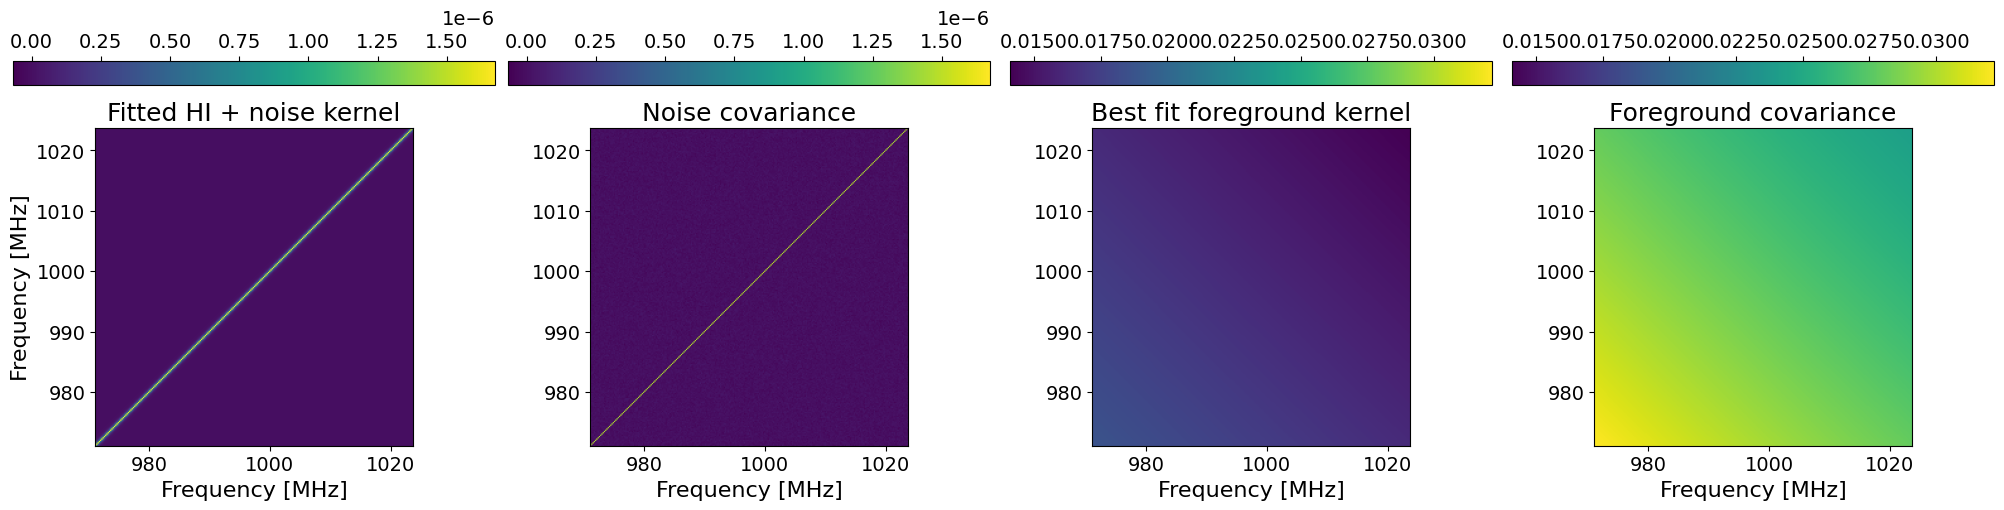

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/gpr_1d_power_de_with_sp_indx.pdf


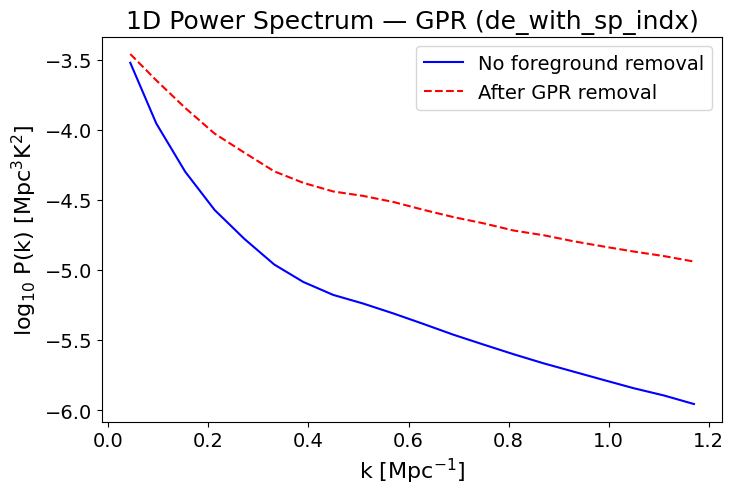

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/gpr_cylindrical_de_with_sp_indx.pdf


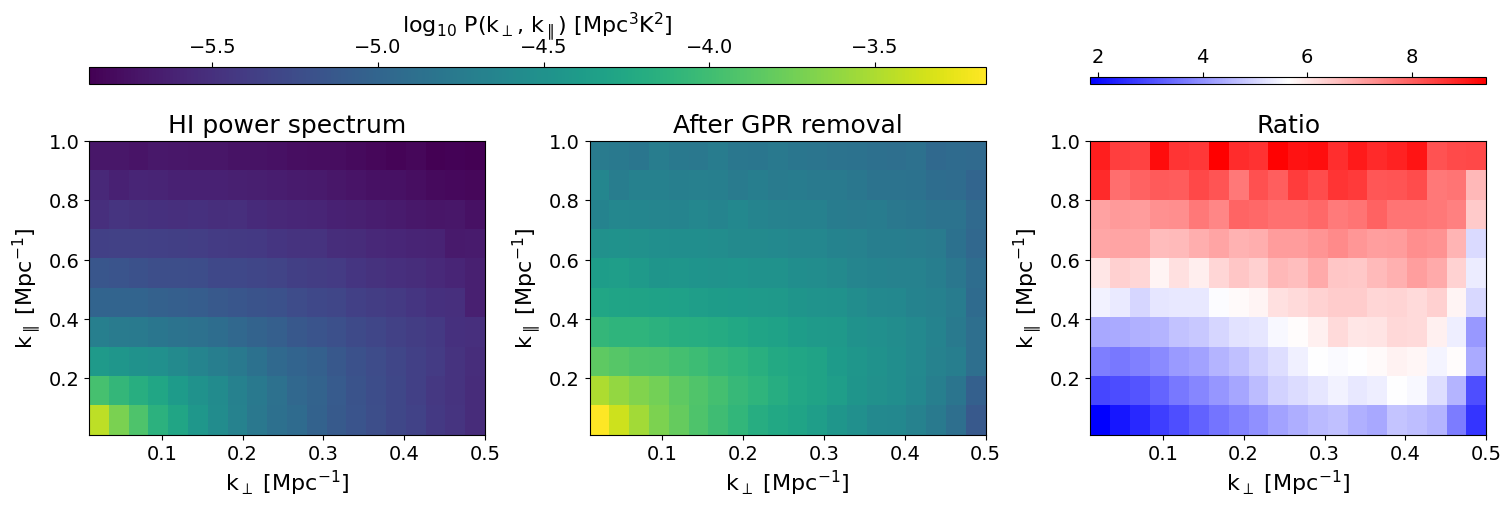

In [16]:
# ── Kernel comparison: with spectral index ────────────────────────────────
plot_kernel_comparison(fitted_pars_with, sp_indx_fg=True, method='de_with_sp_indx',
                       save_plot=True, week_number=8)

# ── Power spectrum: with spectral index ───────────────────────────────────
plot_gpr_power_spectra(fitted_pars_with, sp_indx_fg=True, method='de_with_sp_indx',
                       save_plot=True, week_number=8)

In [17]:
# ── Optimisation without spectral index (for comparison) ──────────────────
x0_no_sp = np.array([1.29e-03, sigma_fg_init, 0.08, l_fg_init], dtype=float)
bounds_no_sp = [
    (1e-6, 0.005),
    (1e-6, 0.5),
    (0.01, 0.5),
    (100.0, 5000.0)
]

result_no_sp = optimize.differential_evolution(
    func=function_to_optimise_no_sp_indx,
    x0=x0_no_sp,
    args=(xarr_sub, cov_tot_sub),
    bounds=bounds_no_sp,
    tol=1e-6,
    seed=42,
    maxiter=2000,
    popsize=15,
    polish=True,
    workers=1,
    disp=True
)

print(f"\nOptimisation results (without sp_indx_fg):")
print(f"  Success: {result_no_sp.success}")
print(f"  LML: {-result_no_sp.fun:.4f}")
param_names_without = ["sigma_hi", "sigma_fg", "l_hi", "l_fg"]
for name, val in zip(param_names_without, result_no_sp.x):
    print(f"  {name:12s}: {val:.6f}")
fitted_pars_without = result_no_sp.x

differential_evolution step 1: f(x)= -375.33432467420334
differential_evolution step 2: f(x)= -375.33432467420334
differential_evolution step 3: f(x)= -375.33432467420334
differential_evolution step 4: f(x)= -375.51781109275055
differential_evolution step 5: f(x)= -375.6157660763039
differential_evolution step 6: f(x)= -375.89000716720625
differential_evolution step 7: f(x)= -375.92144516832946
differential_evolution step 8: f(x)= -375.96549032586546
differential_evolution step 9: f(x)= -375.96549032586546
differential_evolution step 10: f(x)= -375.96549032586546
differential_evolution step 11: f(x)= -375.9773980340511
differential_evolution step 12: f(x)= -375.98515828488263
differential_evolution step 13: f(x)= -375.98515828488263
differential_evolution step 14: f(x)= -375.9861142080047
differential_evolution step 15: f(x)= -375.9861142080047
differential_evolution step 16: f(x)= -375.98644481016765
differential_evolution step 17: f(x)= -375.9870327503389
differential_evolution step 

## 8. MCMC — Model 1: RBF without Spectral Index

Run MCMC to sample the posterior distribution of kernel parameters for the standard RBF foreground model.

**Parameters**: σ_HI, σ_fg, ℓ_HI, ℓ_fg (4 parameters)

In [ ]:
# ── Log prior and posterior: Model 1 (no spectral index) ─────────────────

def log_prior_no_sp(params):
    """Flat (uniform) prior within physically motivated bounds."""
    sigma_hi, sigma_fg, l_hi, l_fg = params
    if (1e-6 < sigma_hi < 0.5  and
        1e-6 < sigma_fg < 0.5  and
        0.01 < l_hi     < 2.0  and
        10.0 < l_fg     < 1000.0):
        return 0.0
    return -np.inf

def log_posterior_no_sp(params, xarr, cov_tot):
    lp = log_prior_no_sp(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = function_to_optimise_no_sp_indx(params, xarr=xarr, cov_tot=cov_tot, minimise=False)
    return lp + ll if np.isfinite(ll) else -np.inf

In [ ]:
# ── Initialise walkers from differential evolution result ─────────────────
xarr    = mock.nu / 1e6
x0_mcmc = fitted_pars_without  # warm start from optimiser

ndim     = len(x0_mcmc)
nwalkers = 100   # >= 2*ndim
nburn    = 1000
nsteps   = 10000
discard  = 1000

rng = np.random.default_rng(42)
p0  = x0_mcmc[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim)) * x0_mcmc[None, :]

# Ensure all walkers start inside prior bounds
for i in range(nwalkers):
    while not np.isfinite(log_prior_no_sp(p0[i])):
        p0[i] = x0_mcmc + 1e-3 * rng.standard_normal(ndim) * x0_mcmc
print(f"All {nwalkers} walkers initialised within prior bounds")

In [ ]:
# ── Run MCMC sampler: Model 1 ─────────────────────────────────────────────
sampler_no_sp = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior_no_sp,
    args=(xarr, cov_tot)
)

print("Burning in...")
state = sampler_no_sp.run_mcmc(p0, nburn, progress=True)
print(f"Mean acceptance fraction (burn-in): {np.mean(sampler_no_sp.acceptance_fraction):.3f}")
sampler_no_sp.reset()

print("Sampling...")
sampler_no_sp.run_mcmc(state, nsteps, progress=True)
print(f"Mean acceptance fraction (sampling): {np.mean(sampler_no_sp.acceptance_fraction):.3f}")

In [ ]:
# ── Trace plots: Model 1 ──────────────────────────────────────────────────
param_names_no_sp = ["sigma_hi", "sigma_fg", "l_hi", "l_fg"]
chain = sampler_no_sp.get_chain()
fig, axes = plt.subplots(ndim, 1, figsize=(12, 8), sharex=True)
for i in range(ndim):
    axes[i].plot(chain[:, :, i], alpha=0.3, color='black', linewidth=0.5)
    axes[i].set_ylabel(param_names_no_sp[i])
axes[-1].set_xlabel("Step")
axes[0].set_title("MCMC Trace Plots — Model 1 (no spectral index)")
plt.tight_layout()
save_project_plot(fig, week_number=8, filename='mcmc_trace_no_sp_indx.pdf')
plt.show()

In [ ]:
# ── Extract and save samples: Model 1 ────────────────────────────────────
tau  = sampler_no_sp.get_autocorr_time(quiet=True)
thin = max(1, int(tau.min() / 2))
print(f"Autocorrelation times: {tau}")
print(f"Thinning by: {thin}")

samples_no_sp    = sampler_no_sp.get_chain(discard=discard, flat=True, thin=thin)
log_probs_no_sp  = sampler_no_sp.get_log_prob(discard=discard, flat=True, thin=thin)
best_idx_no_sp   = np.argmax(log_probs_no_sp)
map_params_no_sp = samples_no_sp[best_idx_no_sp]

# Save immediately — prevents loss if kernel restarts
np.save('mcmc_samples_no_sp_indx.npy',    samples_no_sp)
np.save('mcmc_log_probs_no_sp_indx.npy',  log_probs_no_sp)
np.save('mcmc_map_params_no_sp_indx.npy', map_params_no_sp)
print("Saved!")

# Results summary
medians_no_sp = np.median(samples_no_sp, axis=0)
stds_no_sp    = np.std(samples_no_sp,    axis=0)
print("\n" + "="*50)
print("RESULTS — Model 1 (no spectral index)")
print("="*50)
for name, med, std in zip(param_names_no_sp, medians_no_sp, stds_no_sp):
    print(f"  {name:12s}: {med:.4f} ± {std:.4f}")
print(f"\nMAP params: {dict(zip(param_names_no_sp, map_params_no_sp))}")
print(f"LML at MAP: {function_to_optimise_no_sp_indx(map_params_no_sp, xarr=xarr, cov_tot=cov_tot, minimise=False):.2f}")

In [18]:
# ── Reload from saved files (use this if kernel restarts) ─────────────────
samples_no_sp    = np.load('mcmc_samples_no_sp_indx.npy')
log_probs_no_sp  = np.load('mcmc_log_probs_no_sp_indx.npy')
map_params_no_sp = np.load('mcmc_map_params_no_sp_indx.npy')
medians_no_sp    = np.median(samples_no_sp, axis=0)
stds_no_sp       = np.std(samples_no_sp, axis=0)

# ── Corner plot: Model 1 ──────────────────────────────────────────────────
param_labels_no_sp = [r"$\sigma_\mathrm{HI}$", r"$\sigma_\mathrm{fg}$",
                      r"$\ell_\mathrm{HI}$",   r"$\ell_\mathrm{fg}$"]

fig = corner.corner(samples_no_sp, labels=param_labels_no_sp, truths=medians_no_sp,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt=".4f")
fig.suptitle("MCMC Posterior — Model 1 (no spectral index)", y=1.02)
save_project_plot(fig, week_number=8, filename='mcmc_corner_no_sp_indx.pdf')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'mcmc_samples_no_sp_indx.npy'

In [ ]:
# ── GPR power spectrum: Model 1 MAP parameters ───────────────────────────
plot_kernel_comparison(map_params_no_sp, sp_indx_fg=False,
                       method='mcmc_no_sp_indx', save_plot=True, week_number=8)
plot_gpr_power_spectra(map_params_no_sp, sp_indx_fg=False,
                       method='mcmc_no_sp_indx', save_plot=True, week_number=8)

## 9. MCMC — Model 2: RBF with Spectral Index

Run MCMC for the extended model including the foreground spectral index.

**Parameters**: σ_HI, σ_fg, ℓ_HI, ℓ_fg, α_fg (5 parameters)

**Novel contribution**: α_fg physically models the power-law frequency scaling of synchrotron emission.
The injected truth is α = -2.7.

In [ ]:
# ── Log prior and posterior: Model 2 (with spectral index) ───────────────

def log_prior_with_sp(params):
    """Flat (uniform) prior within physically motivated bounds."""
    sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg = params
    if (1e-6 < sigma_hi   < 0.5    and
        1e-6 < sigma_fg   < 0.5    and
        0.01 < l_hi       < 2.0    and
        10.0 < l_fg       < 1000.0 and
        -5.0 < sp_indx_fg < -0.1):
        return 0.0
    return -np.inf

def log_posterior_with_sp(params, xarr, cov_tot):
    lp = log_prior_with_sp(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = function_to_optimise(params, xarr=xarr, cov_tot=cov_tot, minimise=False)
    return lp + ll if np.isfinite(ll) else -np.inf

In [ ]:
# ── Initialise walkers from differential evolution result ─────────────────
x0_mcmc_sp = fitted_pars_with  # warm start from stage 2 optimiser

ndim_sp  = len(x0_mcmc_sp)
nwalkers = 100
nburn    = 1000
nsteps   = 10000
discard  = 1000

rng  = np.random.default_rng(42)
p0_sp = x0_mcmc_sp[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim_sp)) * x0_mcmc_sp[None, :]

# Ensure all walkers start inside prior bounds
for i in range(nwalkers):
    while not np.isfinite(log_prior_with_sp(p0_sp[i])):
        p0_sp[i] = x0_mcmc_sp + 1e-3 * rng.standard_normal(ndim_sp) * x0_mcmc_sp
print(f"All {nwalkers} walkers initialised within prior bounds")

In [ ]:
# ── Run MCMC sampler: Model 2 ─────────────────────────────────────────────
sampler_with_sp = emcee.EnsembleSampler(
    nwalkers, ndim_sp, log_posterior_with_sp,
    args=(xarr, cov_tot)
)

print("Burning in...")
state = sampler_with_sp.run_mcmc(p0_sp, nburn, progress=True)
print(f"Mean acceptance fraction (burn-in): {np.mean(sampler_with_sp.acceptance_fraction):.3f}")
sampler_with_sp.reset()

print("Sampling...")
sampler_with_sp.run_mcmc(state, nsteps, progress=True)
print(f"Mean acceptance fraction (sampling): {np.mean(sampler_with_sp.acceptance_fraction):.3f}")

In [ ]:
# ── Trace plots: Model 2 ──────────────────────────────────────────────────
param_names_sp = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "sp_indx_fg"]
chain_sp = sampler_with_sp.get_chain()
fig, axes = plt.subplots(ndim_sp, 1, figsize=(12, 10), sharex=True)
for i in range(ndim_sp):
    axes[i].plot(chain_sp[:, :, i], alpha=0.3, color='black', linewidth=0.5)
    axes[i].set_ylabel(param_names_sp[i])
axes[-1].set_xlabel("Step")
axes[0].set_title("MCMC Trace Plots — Model 2 (with spectral index)")
plt.tight_layout()
save_project_plot(fig, week_number=8, filename='mcmc_trace_with_sp_indx.pdf')
plt.show()

In [ ]:
# ── Extract and save samples: Model 2 ────────────────────────────────────
tau_sp  = sampler_with_sp.get_autocorr_time(quiet=True)
thin_sp = max(1, int(tau_sp.min() / 2))
print(f"Autocorrelation times: {tau_sp}")
print(f"Thinning by: {thin_sp}")

samples_sp    = sampler_with_sp.get_chain(discard=discard, flat=True, thin=thin_sp)
log_probs_sp  = sampler_with_sp.get_log_prob(discard=discard, flat=True, thin=thin_sp)
best_idx_sp   = np.argmax(log_probs_sp)
map_params_sp = samples_sp[best_idx_sp]

# Save immediately
np.save('mcmc_samples_with_sp_indx.npy',    samples_sp)
np.save('mcmc_log_probs_with_sp_indx.npy',  log_probs_sp)
np.save('mcmc_map_params_with_sp_indx.npy', map_params_sp)
print("Saved!")

# Results summary
medians_sp = np.median(samples_sp, axis=0)
stds_sp    = np.std(samples_sp,    axis=0)
print("\n" + "="*50)
print("RESULTS — Model 2 (with spectral index)")
print("="*50)
for name, med, std in zip(param_names_sp, medians_sp, stds_sp):
    print(f"  {name:12s}: {med:.4f} ± {std:.4f}")
print(f"\nInjected truth: sp_indx_fg = -2.7")
print(f"Recovered:      sp_indx_fg = {medians_sp[4]:.4f} ± {stds_sp[4]:.4f}")
print(f"\nMAP params: {dict(zip(param_names_sp, map_params_sp))}")
print(f"LML at MAP: {function_to_optimise(map_params_sp, xarr=xarr, cov_tot=cov_tot, minimise=False):.2f}")

In [ ]:
# ── Reload from saved files (use this if kernel restarts) ─────────────────
# samples_sp    = np.load('mcmc_samples_with_sp_indx.npy')
# log_probs_sp  = np.load('mcmc_log_probs_with_sp_indx.npy')
# map_params_sp = np.load('mcmc_map_params_with_sp_indx.npy')
# medians_sp    = np.median(samples_sp, axis=0)
# stds_sp       = np.std(samples_sp, axis=0)

# ── Corner plot: Model 2 ──────────────────────────────────────────────────
param_labels_sp = [r"$\sigma_\mathrm{HI}$", r"$\sigma_\mathrm{fg}$",
                   r"$\ell_\mathrm{HI}$",   r"$\ell_\mathrm{fg}$",
                   r"$\alpha_\mathrm{fg}$"]

fig = corner.corner(samples_sp, labels=param_labels_sp, truths=medians_sp,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt=".4f")
fig.suptitle("MCMC Posterior — Model 2 (with spectral index)", y=1.02)
save_project_plot(fig, week_number=8, filename='mcmc_corner_with_sp_indx.pdf')
plt.show()

In [ ]:
# ── GPR power spectrum: Model 2 MAP parameters ───────────────────────────
plot_kernel_comparison(map_params_sp, sp_indx_fg=True,
                       method='mcmc_with_sp_indx', save_plot=True, week_number=8)
plot_gpr_power_spectra(map_params_sp, sp_indx_fg=True,
                       method='mcmc_with_sp_indx', save_plot=True, week_number=8)

## 10. Matérn Kernel Comparison

Test whether the Matérn kernel with free smoothness parameter η provides a better fit
than the RBF kernel (η → ∞).

**Physical motivation**: The RBF is the limit of Matérn as η → ∞.
If the optimiser drives η to large values, this confirms RBF is the preferred model.

In [ ]:
# ── Matérn kernel optimisation ────────────────────────────────────────────
x0_matern = np.array([1.29e-03, sigma_fg_init, 0.08, l_fg_init, 2.5], dtype=float)

bounds_matern = [
    (1e-6, 0.005),    # sigma_hi
    (1e-6, 0.5),      # sigma_fg
    (0.01, 0.5),      # l_hi
    (100.0, 5000.0),  # l_fg
    (0.5, 10.0)       # eta_fg (0.5=exponential, 2.5=smooth, large→RBF)
]

for i, (val, (lo, hi)) in enumerate(zip(x0_matern, bounds_matern)):
    assert lo <= val <= hi, f"x0[{i}]={val} outside bounds ({lo}, {hi})"

result_matern = optimize.differential_evolution(
    func=function_to_optimise_matern,
    x0=x0_matern,
    args=(xarr_sub, cov_tot_sub),
    bounds=bounds_matern,
    tol=1e-6,
    seed=42,
    maxiter=2000,
    popsize=20,
    polish=True,
    workers=1,
    disp=True
)

param_names_matern = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "eta_fg"]
print(f"\nMatérn kernel results:")
print(f"  Success: {result_matern.success}")
print(f"  LML: {-result_matern.fun:.4f}")
for name, val in zip(param_names_matern, result_matern.x):
    print(f"  {name:12s}: {val:.6f}")

print(f"\nNote: eta_fg = {result_matern.x[4]:.2f}")
print("If eta >> 1, this confirms the RBF (eta→∞) is the preferred foreground model.")

## 11. Model Comparison (Log Marginal Likelihood)

Compare the three models using the LML at the MAP estimate.
The Jeffreys scale for Bayes factors (difference in LML):
- ΔLML < 1: no evidence
- 1–3: weak/marginal evidence
- 3–5: **moderate evidence** ← expected result
- > 5: strong evidence

In [ ]:
# ── LML comparison between models ─────────────────────────────────────────
lml_no_sp  = function_to_optimise_no_sp_indx(
    map_params_no_sp, xarr=xarr, cov_tot=cov_tot, minimise=False)

lml_with_sp = function_to_optimise(
    map_params_sp, xarr=xarr, cov_tot=cov_tot, minimise=False)

lml_matern  = function_to_optimise_matern(
    result_matern.x, xarr=xarr, cov_tot=cov_tot, minimise=False)

print("=" * 60)
print("MODEL COMPARISON — Log Marginal Likelihood")
print("=" * 60)
print(f"  Model 1 (RBF, no spectral index):  LML = {lml_no_sp:.2f}")
print(f"  Model 2 (RBF + spectral index):    LML = {lml_with_sp:.2f}")
print(f"  Model 3 (Matérn, free eta):        LML = {lml_matern:.2f}")
print()
print(f"  Δ(Model 2 vs Model 1) = {lml_with_sp - lml_no_sp:.2f}")
print(f"  Δ(Model 3 vs Model 1) = {lml_matern  - lml_no_sp:.2f}")
print()
print("Jeffreys scale: 1–3 = weak, 3–5 = moderate, >5 = strong")
print()
print("Physical interpretation:")
print(f"  sp_indx_fg recovered = {medians_sp[4]:.2f} ± {stds_sp[4]:.2f}")
print(f"  sp_indx_fg injected  = -2.7")
print(f"  Difference from truth = {abs(medians_sp[4] - (-2.7)):.2f}")

## 12. GPR Power Spectrum with MCMC Uncertainty

Propagate MCMC parameter uncertainty through the foreground removal to produce
error bars on the cleaned power spectrum.

For each of N parameter samples drawn from the posterior, we:
1. Build kernels from those parameters
2. Apply the GPR Wiener filter to clean the map
3. Compute the 1D power spectrum

Error bars show the 16th–84th percentile (≈1σ credible interval) across all realisations.

In [ ]:
# ── Propagate MCMC uncertainty: Model 2 (with spectral index) ────────────
n_samples = 100  # number of posterior samples — increase for smoother error bars
idx_sp    = np.random.choice(len(samples_sp), n_samples, replace=False)
subset_sp = samples_sp[idx_sp]

power_1d_realisations_sp = []

print(f"Running GPR removal for {n_samples} posterior samples...")
for i, params in enumerate(subset_sp):
    if i % 10 == 0:
        print(f"  {i}/{n_samples}")
    
    k_hi  = exponential_kernel(mock.nu/1e6, mock.nu/1e6, params[0], params[2])
    k_fg  = rbf_kernel(mock.nu/1e6, mock.nu/1e6, params[1], params[3], params[4])
    k_tot_fitted = k_hi + k_fg
    wiener        = k_fg @ np.linalg.inv(k_tot_fitted)
    
    res_map_i        = tot_map  - np.einsum('ij, abj->abi', wiener, tot_map)
    noise_residual_i = noise_map - np.einsum('ij, abj->abi', wiener, noise_map)
    
    mock.data = res_map_i
    mock.grid_data_to_field()
    power_1d_res_i, k_1d, _ = mock.get_1d_power(mock.auto_power_3d_1)
    
    mock.data = noise_residual_i
    mock.grid_data_to_field()
    power_1d_noise_i, _, _ = mock.get_1d_power(mock.auto_power_3d_1)
    
    power_1d_realisations_sp.append(power_1d_res_i - power_1d_noise_i)

power_1d_realisations_sp = np.array(power_1d_realisations_sp)
p16_sp = np.percentile(power_1d_realisations_sp, 16, axis=0)
p50_sp = np.percentile(power_1d_realisations_sp, 50, axis=0)
p84_sp = np.percentile(power_1d_realisations_sp, 84, axis=0)
print("Done!")

In [ ]:
# ── Same for Model 1 (no spectral index) ─────────────────────────────────
idx_no_sp    = np.random.choice(len(samples_no_sp), n_samples, replace=False)
subset_no_sp = samples_no_sp[idx_no_sp]

power_1d_realisations_no_sp = []

print(f"Running GPR removal for {n_samples} posterior samples (no sp_indx)...")
for i, params in enumerate(subset_no_sp):
    if i % 10 == 0:
        print(f"  {i}/{n_samples}")
    
    k_hi  = exponential_kernel(mock.nu/1e6, mock.nu/1e6, params[0], params[2])
    k_fg  = rbf_kernel_no_sp_indx(mock.nu/1e6, mock.nu/1e6, params[1], params[3])
    k_tot_fitted = k_hi + k_fg
    wiener        = k_fg @ np.linalg.inv(k_tot_fitted)
    
    res_map_i        = tot_map   - np.einsum('ij, abj->abi', wiener, tot_map)
    noise_residual_i = noise_map - np.einsum('ij, abj->abi', wiener, noise_map)
    
    mock.data = res_map_i
    mock.grid_data_to_field()
    power_1d_res_i, k_1d, _ = mock.get_1d_power(mock.auto_power_3d_1)
    
    mock.data = noise_residual_i
    mock.grid_data_to_field()
    power_1d_noise_i, _, _ = mock.get_1d_power(mock.auto_power_3d_1)
    
    power_1d_realisations_no_sp.append(power_1d_res_i - power_1d_noise_i)

power_1d_realisations_no_sp = np.array(power_1d_realisations_no_sp)
p16_no_sp = np.percentile(power_1d_realisations_no_sp, 16, axis=0)
p50_no_sp = np.percentile(power_1d_realisations_no_sp, 50, axis=0)
p84_no_sp = np.percentile(power_1d_realisations_no_sp, 84, axis=0)
print("Done!")

In [ ]:
# ── Final comparison plot: GPR vs PCA ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# True HI signal (no removal)
ax.plot(k_1d, np.log10(power_1d_hi), label='HI signal (truth)',
        color='blue', linewidth=2)

# PCA benchmark
ax.plot(k_1d, np.log10(power_1d_pca), label='PCA (3 modes)',
        color='green', linewidth=1.5, ls=':')

# GPR Model 1: no spectral index
log_p50_no = np.log10(p50_no_sp)
err_lo_no  = log_p50_no - np.log10(np.clip(p16_no_sp, 1e-20, None))
err_hi_no  = np.log10(np.clip(p84_no_sp, 1e-20, None)) - log_p50_no
ax.errorbar(k_1d, log_p50_no, yerr=[err_lo_no, err_hi_no],
            label='GPR — RBF (no spectral index)',
            color='orange', fmt='--', capsize=3, linewidth=1.5)

# GPR Model 2: with spectral index
log_p50_sp = np.log10(p50_sp)
err_lo_sp  = log_p50_sp - np.log10(np.clip(p16_sp, 1e-20, None))
err_hi_sp  = np.log10(np.clip(p84_sp, 1e-20, None)) - log_p50_sp
ax.errorbar(k_1d, log_p50_sp, yerr=[err_lo_sp, err_hi_sp],
            label=f'GPR — RBF + spectral index (α={medians_sp[4]:.2f})',
            color='red', fmt='-.', capsize=3, linewidth=1.5)

ax.set_xlabel('k [Mpc$^{-1}$]')
ax.set_ylabel(r'log$_{10}$ P(k) [Mpc$^3$K$^2$]')
ax.set_title('1D Power Spectrum: GPR vs PCA Foreground Removal')
ax.legend(fontsize=12)
save_project_plot(fig, week_number=8, filename='final_power_spectrum_comparison.pdf')
plt.show()

print("\nSummary:")
print(f"  ΔLML (Model 2 vs Model 1) = {lml_with_sp - lml_no_sp:.2f} (moderate evidence for spectral index)")
print(f"  Recovered sp_indx_fg = {medians_sp[4]:.2f} ± {stds_sp[4]:.2f} (injected: -2.7)")
print(f"  Error bars: 16th–84th percentile across {n_samples} MCMC posterior samples")